# Análise Comparativa Final — Exato, Construtivo, Busca Local e ILS para o CVRP da Prolog

**ENG 4560 — Projeto Integrado VI: Distribuição Física | Grupo 2**

As Sprints 1 e 2 desenvolveram, em aulas separadas, quatro famílias de método para o CVRP da Prolog: o modelo exato MILP com Gurobi (Aula 4), as heurísticas construtivas Nearest Neighbor e Clarke & Wright (Aula 7), a busca local 2-opt + Relocate + Swap (Aula 8) e a metaheurística Iterated Local Search (Aulas 11 e 12). Cada notebook mediu seus próprios resultados em sessões distintas. Este notebook consolida tudo numa única comparação e responde à pergunta da Sprint 3: qual abordagem é mais adequada para cada tamanho de instância, considerando custo, tempo e qualidade.

A consolidação enfrenta dois problemas de comparabilidade que os notebooks isolados não resolvem. O primeiro é o tempo: medições feitas em sessões diferentes não são comparáveis entre si, porque o relógio depende da carga da máquina. Por isso, as etapas heurísticas de custo computacional não desprezível — busca local e ILS — são reexecutadas aqui numa única sessão, e o custo de toda solução é reavaliado pela mesma função objetivo. O segundo é o gap de otimalidade: o MILP da Aula 4 resolve uma formulação relaxada (frota como tipo único por veículo, capacidade agregada, sem jornada de 8 h) e suas soluções para C2–C4 são inviáveis no problema real. O gap contra o exato só é legítimo onde os regimes coincidem, o que ocorre apenas em C1. Essa restrição, estabelecida na Aula 11, orienta toda a leitura comparativa.

O estudo cobre as quatro instâncias C1–C4 (10, 25, 40 e 60 clientes) e segue esta ordem: (0) ambiente e biblioteca unificada de avaliação; (1) método exato e seus limites; (2) pipeline heurístico reexecutado em sessão única; (3) tabela e gráficos comparativos; (4) síntese e recomendação operacional por tamanho de instância.

## Seção 0 — Ambiente, instâncias e biblioteca unificada

Esta seção prepara o que a comparação consome. As funções de avaliação de custo, viabilidade, busca local e ILS reproduzem o código de referência das Aulas 8 e 12 do professor — a mesma biblioteca usada na análise de sensibilidade —, garantindo que toda solução, de qualquer método, seja medida pela função objetivo idêntica: custo fixo do veículo mais custo variável por quilômetro, com viabilidade exigindo capacidade por rota e jornada de 8 h. Em seguida, carregamos as quatro instâncias C1–C4 (Aula 2) e as soluções salvas de cada método heurístico (construtivas da Aula 7, busca local da Aula 8, ILS da Aula 11) e reavaliamos o custo de cada uma sob essa função única, o que torna os custos diretamente comparáveis independentemente de como cada notebook original os calculou.

In [1]:
import json
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Raiz do projeto: sobe ate encontrar a pasta Aulas (robusto ao diretorio de trabalho)
BASE = Path.cwd()
while not (BASE / "Aulas").exists() and BASE != BASE.parent:
    BASE = BASE.parent

DATASETS_DIR = BASE / "Aulas/2/datasets"
DIR_CONSTRUTIVA = BASE / "Aulas/7/Aula7_Heuristicas_Construtivas/files"
DIR_BUSCA_LOCAL = BASE / "Aulas/8/Aula8_Busca_Local/files"
DIR_ILS = BASE / "Aulas/11/Aula11_ILS/files"
OUT_FILES = Path("files"); OUT_FILES.mkdir(exist_ok=True)
OUT_IMAGES = Path("images"); OUT_IMAGES.mkdir(exist_ok=True)

INSTANCIAS = {"C1": "Equipe_2_C1_10", "C2": "Equipe_2_C2_25",
              "C3": "Equipe_2_C3_40", "C4": "Equipe_2_C4_60"}

# Paleta por familia de metodo (consistente nos graficos)
CORES = {"exato": "#5E35B1", "construtiva": "#9E9E9E",
         "busca_local": "#1E88E5", "ils": "#2E7D32"}

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

assert DATASETS_DIR.exists(), f"Datasets nao encontrados: {DATASETS_DIR}"
print("Raiz do projeto:", BASE)
print("Instancias:", list(INSTANCIAS))

Raiz do projeto: C:\Users\rodri\OneDrive\Documentos\Claude\Cowork\Proj. Distribuição Fisica
Instancias: ['C1', 'C2', 'C3', 'C4']


In [2]:
# Biblioteca de avaliacao e viabilidade (fiel ao codigo de referencia das Aulas 8 e 12)

def normalize_params(params_raw):
    if all(k in params_raw for k in ["capacity", "fixed_cost", "cost_per_km", "speed_kmh", "max_hours"]):
        return {k: params_raw[k] for k in ["capacity", "fixed_cost", "cost_per_km", "speed_kmh", "max_hours"]}
    if "VEHICLES" in params_raw:
        capacity, fixed_cost = {}, {}
        for key, val in params_raw["VEHICLES"].items():
            ku = key.upper()
            name = "FIO" if ku in ("FIO", "FIORINO") else ("VUC" if ku == "VUC" else ku)
            capacity[name] = val.get("Q_kg", val.get("capacity"))
            fixed_cost[name] = val.get("fixed_cost", val.get("custo_fixo_diario"))
        return {"capacity": capacity, "fixed_cost": fixed_cost,
                "cost_per_km": params_raw.get("cost_per_km", params_raw.get("g_R$/km", 1.50)),
                "speed_kmh": params_raw.get("speed_kmh", params_raw.get("v_kmh", 40.0)),
                "max_hours": params_raw.get("max_hours", params_raw.get("H_horas", 8.0))}
    raise ValueError("Formato de params.json nao reconhecido.")

def normalize_vehicle_name(v):
    v = str(v).upper()
    if v in ("FIO", "FIORINO"):
        return "FIO"
    if v == "VUC":
        return "VUC"
    raise ValueError(f"Tipo de veiculo desconhecido: {v}")

def normalize_solution(solution):
    return [{"route_id": it.get("route_id", i + 1),
             "vehicle": normalize_vehicle_name(it["vehicle"]),
             "route": [int(x) for x in it["route"]]} for i, it in enumerate(solution)]

def route_distance(route, D):
    return sum(D[route[i], route[i + 1]] for i in range(len(route) - 1))

def route_load(route, q):
    return sum(q[nd] for nd in route if nd != 0)

def route_total_time(route, D, s, v_kmh):
    t_mov = route_distance(route, D) / v_kmh
    t_serv = sum(s[nd] for nd in route if nd != 0)
    return t_mov + t_serv, t_mov, t_serv

def route_cost(route, vehicle_type, D, params):
    if not any(nd != 0 for nd in route):
        return 0.0
    vehicle_type = normalize_vehicle_name(vehicle_type)
    return params["fixed_cost"][vehicle_type] + params["cost_per_km"] * route_distance(route, D)

def total_solution_cost(solution, D, params):
    return sum(route_cost(r["route"], r["vehicle"], D, params) for r in solution)

def is_route_feasible(route, vehicle_type, D, q, s, params):
    vehicle_type = normalize_vehicle_name(vehicle_type)
    if route_load(route, q) > params["capacity"][vehicle_type] + 1e-6:
        return False
    t, _, _ = route_total_time(route, D, s, params["speed_kmh"])
    return t <= params["max_hours"] + 1e-6

def is_solution_feasible(solution, D, q, s, params):
    visited = []
    for r in solution:
        route, vehicle = r["route"], normalize_vehicle_name(r["vehicle"])
        if route[0] != 0 or route[-1] != 0:
            return False
        if not is_route_feasible(route, vehicle, D, q, s, params):
            return False
        visited.extend(nd for nd in route if nd != 0)
    return sorted(visited) == list(range(1, len(q)))

def solution_metrics(solution, D, q, s, params):
    total_dist = total_time = total_cost = 0.0
    n_fio = n_vuc = 0
    for item in solution:
        route, vehicle = item["route"], normalize_vehicle_name(item["vehicle"])
        total_dist += route_distance(route, D)
        total_time += route_total_time(route, D, s, params["speed_kmh"])[0]
        total_cost += route_cost(route, vehicle, D, params)
        n_fio += vehicle == "FIO"
        n_vuc += vehicle == "VUC"
    return {"n_routes": len(solution), "n_fio": n_fio, "n_vuc": n_vuc,
            "total_distance_km": total_dist, "total_time_h": total_time,
            "total_cost_rs": total_cost,
            "feasible": is_solution_feasible(solution, D, q, s, params)}

print("Biblioteca de avaliacao e viabilidade carregada.")

Biblioteca de avaliacao e viabilidade carregada.


In [3]:
# Movimentos de busca local, perturbacoes e laco ILS (fiel ao codigo de referencia das Aulas 8, 11 e 12)

def two_opt_swap(route, i, k):
    return route[:i] + route[i:k + 1][::-1] + route[k + 1:]

def improve_route_2opt(route, vehicle_type, D, q, s, params):
    best_route = route.copy()
    best_dist = route_distance(best_route, D)
    improved = True
    while improved:
        improved = False
        for i in range(1, len(best_route) - 2):
            for k in range(i + 1, len(best_route) - 1):
                candidate = two_opt_swap(best_route, i, k)
                if not is_route_feasible(candidate, vehicle_type, D, q, s, params):
                    continue
                if route_distance(candidate, D) < best_dist - 1e-6:
                    best_route, best_dist, improved = candidate, route_distance(candidate, D), True
                    break
            if improved:
                break
    return best_route

def apply_2opt(solution, D, q, s, params):
    return [{"route_id": it["route_id"], "vehicle": it["vehicle"],
             "route": improve_route_2opt(it["route"], it["vehicle"], D, q, s, params)} for it in solution]

def relocate_customer(route_from, route_to, idx_from, idx_to):
    new_from, new_to = route_from.copy(), route_to.copy()
    new_to.insert(idx_to, new_from.pop(idx_from))
    return new_from, new_to

def apply_relocate(solution, D, q, s, params):
    best_solution = copy.deepcopy(solution)
    best_cost = total_solution_cost(best_solution, D, params)
    improved = True
    while improved:
        improved = False
        for a in range(len(best_solution)):
            for b in range(len(best_solution)):
                if a == b:
                    continue
                rf, rt = best_solution[a]["route"], best_solution[b]["route"]
                for idx_from in range(1, len(rf) - 1):
                    for idx_to in range(1, len(rt)):
                        cand = copy.deepcopy(best_solution)
                        nf, nt = relocate_customer(cand[a]["route"], cand[b]["route"], idx_from, idx_to)
                        cand[a]["route"], cand[b]["route"] = nf, nt
                        cand = [it for it in cand if len([n for n in it["route"] if n != 0]) > 0]
                        for rid, it in enumerate(cand, start=1):
                            it["route_id"] = rid
                        if not is_solution_feasible(cand, D, q, s, params):
                            continue
                        if total_solution_cost(cand, D, params) < best_cost - 1e-6:
                            best_solution, best_cost, improved = copy.deepcopy(cand), total_solution_cost(cand, D, params), True
                            break
                    if improved:
                        break
                if improved:
                    break
            if improved:
                break
    return best_solution

def swap_customers(route_a, route_b, idx_a, idx_b):
    na, nb = route_a.copy(), route_b.copy()
    na[idx_a], nb[idx_b] = nb[idx_b], na[idx_a]
    return na, nb

def apply_swap(solution, D, q, s, params):
    best_solution = copy.deepcopy(solution)
    best_cost = total_solution_cost(best_solution, D, params)
    improved = True
    while improved:
        improved = False
        for a in range(len(best_solution)):
            for b in range(a + 1, len(best_solution)):
                ra, rb = best_solution[a]["route"], best_solution[b]["route"]
                for idx_a in range(1, len(ra) - 1):
                    for idx_b in range(1, len(rb) - 1):
                        cand = copy.deepcopy(best_solution)
                        na, nb = swap_customers(cand[a]["route"], cand[b]["route"], idx_a, idx_b)
                        cand[a]["route"], cand[b]["route"] = na, nb
                        if not is_solution_feasible(cand, D, q, s, params):
                            continue
                        if total_solution_cost(cand, D, params) < best_cost - 1e-6:
                            best_solution, best_cost, improved = copy.deepcopy(cand), total_solution_cost(cand, D, params), True
                            break
                    if improved:
                        break
                if improved:
                    break
            if improved:
                break
    return best_solution

def local_search(solution, D, q, s, params, use_2opt=True, use_relocate=True, use_swap=False):
    current = copy.deepcopy(solution)
    if use_2opt:
        current = apply_2opt(current, D, q, s, params)
    if use_relocate:
        current = apply_relocate(current, D, q, s, params)
    if use_swap:
        current = apply_swap(current, D, q, s, params)
    return current

def perturb_double_bridge(solution, D, q, s, params, rng, k=1):
    candidate = copy.deepcopy(solution)
    for _ in range(k):
        valid = [i for i, it in enumerate(candidate) if len([n for n in it["route"] if n != 0]) >= 4]
        if not valid:
            return copy.deepcopy(solution)
        r_idx = rng.choice(valid)
        clients = candidate[r_idx]["route"][1:-1]
        if len(clients) < 4:
            continue
        a, b, c = sorted(rng.sample(range(1, len(clients)), 3))
        candidate[r_idx]["route"] = [0] + clients[:a] + clients[b:c] + clients[a:b] + clients[c:] + [0]
    return candidate if is_solution_feasible(candidate, D, q, s, params) else copy.deepcopy(solution)

def accept_solution(cost_new, cost_current, criterion="strict", tolerance_pct=0.03):
    if cost_new < cost_current - 1e-6:
        return True
    if criterion == "strict":
        return False
    if criterion == "tolerance":
        return cost_new <= cost_current * (1.0 + tolerance_pct)
    raise ValueError(criterion)

def iterated_local_search(initial_solution, D, q, s, params, n_iterations=100, seed=42,
                          perturbation_k=1, accept_criterion="strict", tolerance_pct=0.0,
                          use_2opt=True, use_relocate=True, use_swap=False):
    rng = random.Random(seed)
    current = local_search(initial_solution, D, q, s, params, use_2opt, use_relocate, use_swap)
    current_cost = total_solution_cost(current, D, params)
    best, best_cost = copy.deepcopy(current), current_cost
    history = [{"iteration": 0, "current_cost": current_cost, "best_cost": best_cost}]
    for it in range(1, n_iterations + 1):
        perturbed = perturb_double_bridge(current, D, q, s, params, rng, k=perturbation_k)
        improved = local_search(perturbed, D, q, s, params, use_2opt, use_relocate, use_swap)
        cand_cost = total_solution_cost(improved, D, params)
        if accept_solution(cand_cost, current_cost, accept_criterion, tolerance_pct):
            current, current_cost = copy.deepcopy(improved), cand_cost
        if cand_cost < best_cost - 1e-6:
            best, best_cost = copy.deepcopy(improved), cand_cost
        history.append({"iteration": it, "current_cost": current_cost, "best_cost": best_cost})
    return best, history

print("Biblioteca de busca local e ILS carregada (perturbacao double-bridge, criterio estrito).")

Biblioteca de busca local e ILS carregada (perturbacao double-bridge, criterio estrito).


In [4]:
# Carrega instancias C1-C4 e as solucoes salvas de cada metodo heuristico

def load_instance(name):
    fo = DATASETS_DIR / INSTANCIAS[name]
    return {"D": np.load(fo / "D.npy"), "q": np.load(fo / "q.npy"),
            "s": np.load(fo / "s.npy"),
            "params": normalize_params(json.loads((fo / "params.json").read_text(encoding="utf-8"))),
            "n_cli": len(np.load(fo / "q.npy")) - 1}

def load_solution(path):
    d = json.loads(Path(path).read_text(encoding="utf-8"))
    sol = d["solution"] if isinstance(d, dict) and "solution" in d else d
    return normalize_solution(sol)

INST = {n: load_instance(n) for n in INSTANCIAS}

# Caminhos das solucoes salvas por (metodo, trilha, instancia)
PATHS = {
    "construtiva": lambda tr, n: DIR_CONSTRUTIVA / f"solution_{tr}_het_{n}_total_cost.json",
    "busca_local": lambda tr, n: DIR_BUSCA_LOCAL / f"solution_busca_local_{tr}_{n}.json",
    "ils":         lambda tr, n: DIR_ILS / f"solution_ils_equipe2_{tr}_{n}.json",
}
SOLUCOES = {met: {tr: {n: load_solution(fn(tr, n)) for n in INSTANCIAS}
                  for tr in ("nn", "cw")} for met, fn in PATHS.items()}

print("Instancias carregadas:", {n: INST[n]["n_cli"] for n in INSTANCIAS})
print("Metodos com solucao salva:", list(SOLUCOES))
print("Trilhas:", list(SOLUCOES["ils"]))

Instancias carregadas: {'C1': 10, 'C2': 25, 'C3': 40, 'C4': 60}
Metodos com solucao salva: ['construtiva', 'busca_local', 'ils']
Trilhas: ['nn', 'cw']


## Seção 1 — O método exato e seus limites

O CVRP é NP-difícil: o esforço para provar otimalidade cresce exponencialmente com o número de clientes. A Aula 4 formulou o problema como um MILP com frota heterogênea e restrições MTZ e o resolveu com o Gurobi, impondo um limite de tempo de 300 s por instância. Os resultados abaixo reproduzem o que aquele notebook registrou; o exato não é reexecutado aqui porque, ao contrário das heurísticas, sua execução não é barata — duas das quatro instâncias esgotam o orçamento de tempo sem prova de otimalidade.

Antes de usar esses números como referência de qualidade, é preciso registrar a divergência de formulação que a Aula 11 documentou. O MILP da Aula 4 trata o conjunto de veículos como tipos com saída única (no máximo uma rota Fiorino e uma rota VUC), usa capacidade agregada e não impõe a jornada de 8 h, validada apenas em pós-processamento. O pipeline heurístico, ao contrário, permite vários Fiorinos, impõe capacidade por rota e respeita a jornada. São problemas diferentes, e por isso o custo do exato não serve como denominador de gap de otimalidade exceto onde os dois regimes coincidem.

In [5]:
# Resultados do metodo exato registrados na Aula 4 (Gurobi, limite de 300 s; nao reexecutados aqui).
# Fonte: Aulas/4/Aula4_Modelagem_MILP_Parte2/notebook.ipynb (tabela comparativa MTZ + frota heterogenea).
EXATO = {
    "C1": {"custo": 422.38, "frota": "1 FIO", "tempo_s": 0.27,  "status": "optimal",      "viola_jornada": 0},
    "C2": {"custo": 754.04, "frota": "1 VUC", "tempo_s": 52.69, "status": "optimal",      "viola_jornada": 1},
    "C3": {"custo": 769.65, "frota": "1 VUC", "tempo_s": 300.73,"status": "maxTimeLimit", "viola_jornada": 1},
    "C4": {"custo": 858.31, "frota": "1 VUC", "tempo_s": 300.88,"status": "maxTimeLimit", "viola_jornada": 1},
}

df_exato = pd.DataFrame([
    {"instancia": n, "n_cli": INST[n]["n_cli"], "custo_rs": e["custo"], "frota": e["frota"],
     "tempo_s": e["tempo_s"], "status": e["status"],
     "viola_jornada": e["viola_jornada"],
     "viavel_real": e["viola_jornada"] == 0}
    for n, e in EXATO.items()
])
display(df_exato.set_index("instancia").round(2))

,n_cli,custo_rs,frota,tempo_s,status,viola_jornada,viavel_real
instancia,,,,,,,
C1,10,422.38,1 FIO,0.27,optimal,0,True
C2,25,754.04,1 VUC,52.69,optimal,1,False
C3,40,769.65,1 VUC,300.73,maxTimeLimit,1,False
C4,60,858.31,1 VUC,300.88,maxTimeLimit,1,False


A tabela expõe os dois limites do método exato. O primeiro é o tempo. Em C1 (10 clientes) o Gurobi prova otimalidade em 0,27 s; em C2 (25 clientes) ainda prova, mas leva 52,69 s — quase duzentas vezes mais para 2,5 vezes mais clientes. Em C3 e C4 o solver atinge o limite de 300 s e retorna com status `maxTimeLimit`: a solução de R$ 769,65 e R$ 858,31 é a melhor encontrada, não a ótima comprovada. É a assinatura da complexidade exponencial do CVRP — o exato deixa de ser viável como ferramenta de decisão a partir de algumas dezenas de clientes.

O segundo limite é a viabilidade. As soluções de C2, C3 e C4 consolidam toda a demanda num único VUC e violam a jornada de 8 h, que o MILP não impôs. O caso é gritante em C3 e C4: 40 e 60 clientes a 0,25 h de atendimento somam 10 h e 15 h só de serviço, muito acima do turno. Essas soluções são operacionalmente inexequíveis. A consequência para a comparação é direta e decisiva: apenas em C1 o exato entrega um ótimo viável no mesmo regime de frota do pipeline heurístico (uma rota Fiorino), e somente ali o gap de otimalidade contra o exato tem significado. Para C2–C4, o número do exato é a solução de um problema mais frouxo, e a referência honesta de qualidade passa a ser a melhor solução viável encontrada pelo pipeline heurístico.

## Seção 2 — Pipeline heurístico reexecutado em sessão única

Para que os tempos sejam comparáveis entre si, as duas etapas de custo computacional não desprezível são reexecutadas aqui, na mesma máquina e na mesma sessão: a busca local (2-opt + Relocate + Swap, partindo da solução construtiva, como na Aula 8) e o ILS (configuração da Equipe 2 — perturbação double-bridge, critério estrito, `k = 2` selecionado na análise de sensibilidade da Aula 12, 100 iterações, semente 42, partindo da solução de busca local). A heurística construtiva não é reexecutada: ela é determinística e roda em frações de segundo, abaixo do que distingue os demais métodos; seu custo é reavaliado da solução salva.

Usamos a trilha Nearest Neighbor, que venceu a Clarke & Wright nas instâncias maiores (C3 e C4) na Aula 11 e empatou nas menores. A coluna `busca_local` reexecutada é confrontada com o custo da solução salva da Aula 8 (`bl_salvo`) para confirmar que a reexecução reproduz fielmente o resultado original.

In [6]:
# Reexecucao do pipeline heuristico na trilha NN, com tempos medidos em uma unica sessao
CONFIG_ILS = dict(perturbation_k=2, accept_criterion="strict", tolerance_pct=0.0,
                  use_2opt=True, use_relocate=True, use_swap=False)
N_ILS = 100
TRILHA = "nn"

reexec = []
for n in INSTANCIAS:
    D, q, s, P = INST[n]["D"], INST[n]["q"], INST[n]["s"], INST[n]["params"]

    sol_con = SOLUCOES["construtiva"][TRILHA][n]
    custo_con = total_solution_cost(sol_con, D, P)

    t0 = time.time()
    sol_bl = local_search(sol_con, D, q, s, P, use_2opt=True, use_relocate=True, use_swap=True)
    t_bl = time.time() - t0
    custo_bl = total_solution_cost(sol_bl, D, P)

    t0 = time.time()
    sol_ils, _ = iterated_local_search(sol_bl, D, q, s, P, n_iterations=N_ILS, seed=SEED, **CONFIG_ILS)
    t_ils = time.time() - t0
    custo_ils = total_solution_cost(sol_ils, D, P)

    reexec.append({
        "instancia": n, "n_cli": INST[n]["n_cli"],
        "construtiva": custo_con,
        "busca_local": custo_bl, "bl_salvo": total_solution_cost(SOLUCOES["busca_local"][TRILHA][n], D, P),
        "t_bl_s": t_bl, "ils": custo_ils, "t_ils_s": t_ils,
        "viavel_ils": is_solution_feasible(sol_ils, D, q, s, P),
        "_sol_ils": sol_ils,
    })

df_reexec = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in reexec]).set_index("instancia")
display(df_reexec.round({"construtiva": 2, "busca_local": 2, "bl_salvo": 2, "t_bl_s": 2, "ils": 2, "t_ils_s": 2}))

,n_cli,construtiva,busca_local,bl_salvo,t_bl_s,ils,t_ils_s,viavel_ils
instancia,,,,,,,,
C1,10,430.60,422.38,422.38,0.00,422.38,0.23,True
C2,25,801.08,712.49,712.49,0.10,710.47,2.51,True
C3,40,1084.86,1043.69,1043.69,0.34,775.01,4.71,True
C4,60,1527.56,1410.00,1410.00,2.73,1383.14,30.51,True


A validação fecha: a busca local reexecutada coincide com a solução salva da Aula 8 em todas as instâncias (C4 = R$ 1.410,00 em ambas as colunas), confirmando que o pipeline reproduz o resultado original e que os tempos medidos aqui descrevem o mesmo cálculo. As soluções do ILS permanecem todas viáveis.

A progressão de custo na trilha NN mostra que o grosso da economia vem da busca local, não da metaheurística. Em C1, a construtiva de R$ 430,60 já cai para o ótimo de R$ 422,38 só com 2-opt + Relocate + Swap, e o ILS não acrescenta nada. Em C2 e C4 o padrão se repete: a queda grande é construtiva → busca local (R$ 801,08 → R$ 712,49 em C2; R$ 1.527,56 → R$ 1.410,00 em C4), e o ILS apara mais alguns reais (R$ 710,47 e R$ 1.383,14). A exceção aparente é C3, onde o ILS derruba o custo de R$ 1.043,69 para R$ 775,01 — uma queda de 25,7%. Como a Aula 12 estabeleceu, esse salto não é mérito das perturbações: é o efeito de não idempotência da busca local. A solução NN-C3 salva na Aula 8 não era um ótimo local de 2-opt + Relocate, e a reaplicação desses operadores na iteração 0 do ILS é o que a melhora; o ganho das perturbações double-bridge propriamente ditas fica abaixo de 1%.

Os tempos confirmam a hierarquia esperada. A busca local roda em menos de 3 s mesmo em C4; o ILS, por reaplicar Relocate a cada uma das 100 iterações, é a etapa cara, partindo de frações de segundo em C1 e chegando à casa dos 30 s em C4. Ainda assim, todo o pipeline heurístico para 60 clientes cabe em torno de meio minuto — uma ordem de grandeza distinta dos 300 s em que o exato sequer prova otimalidade. Os tempos de busca local e ILS são medições de relógio e oscilam alguns por cento entre execuções na mesma máquina; os valores determinísticos de custo e gap não.

## Seção 3 — Comparação consolidada

### 3.1 Tabela método × instância × custo × tempo × gap

A tabela reúne os quatro métodos sobre as quatro instâncias. O custo é o da função objetivo unificada; o tempo segue a procedência descrita acima (exato da Aula 4; construtiva da Aula 7, sub-segundo; busca local e ILS medidos nesta sessão). A coluna `gap_pct` mede a distância percentual à melhor solução **viável** encontrada em cada instância, que é sempre a do ILS. Em C1 essa melhor solução viável coincide com o ótimo provado pelo exato, então ali o gap é o gap de otimalidade no sentido clássico. Em C2–C4, como o exato é inviável, a melhor viável é a referência honesta de qualidade e o gap do exato fica indefinido — registrar um gap de otimalidade contra uma solução que viola a jornada não teria sentido.

In [7]:
# Monta a tabela consolidada (long): metodo x instancia x custo x tempo x gap
def tempo_construtiva(n):
    d = json.loads((DIR_CONSTRUTIVA / f"solution_nn_het_{n}_total_cost.json").read_text(encoding="utf-8"))
    return float(d.get("elapsed_s", d.get("elapsed_sec", float("nan"))))

melhor_viavel = {n: float(df_reexec.loc[n, "ils"]) for n in INSTANCIAS}  # ILS = melhor solucao viavel

linhas = []
for n in INSTANCIAS:
    ref = melhor_viavel[n]
    e = EXATO[n]
    linhas.append({"metodo": "Exato (MILP)", "instancia": n, "n_cli": INST[n]["n_cli"],
                   "custo_rs": e["custo"], "tempo_s": e["tempo_s"], "viavel": e["viola_jornada"] == 0,
                   "gap_pct": 0.0 if n == "C1" else np.nan})
    linhas.append({"metodo": "Construtiva (NN)", "instancia": n, "n_cli": INST[n]["n_cli"],
                   "custo_rs": float(df_reexec.loc[n, "construtiva"]), "tempo_s": tempo_construtiva(n), "viavel": True,
                   "gap_pct": (float(df_reexec.loc[n, "construtiva"]) - ref) / ref * 100})
    linhas.append({"metodo": "Busca local", "instancia": n, "n_cli": INST[n]["n_cli"],
                   "custo_rs": float(df_reexec.loc[n, "busca_local"]), "tempo_s": float(df_reexec.loc[n, "t_bl_s"]), "viavel": True,
                   "gap_pct": (float(df_reexec.loc[n, "busca_local"]) - ref) / ref * 100})
    linhas.append({"metodo": "ILS", "instancia": n, "n_cli": INST[n]["n_cli"],
                   "custo_rs": float(df_reexec.loc[n, "ils"]), "tempo_s": float(df_reexec.loc[n, "t_ils_s"]), "viavel": True,
                   "gap_pct": 0.0})

ORDEM = ["Exato (MILP)", "Construtiva (NN)", "Busca local", "ILS"]
df_comp = pd.DataFrame(linhas)
df_comp["metodo"] = pd.Categorical(df_comp["metodo"], categories=ORDEM, ordered=True)
df_comp = df_comp.sort_values(["instancia", "metodo"]).reset_index(drop=True)

display(df_comp.assign(
    custo_rs=df_comp["custo_rs"].round(2),
    tempo_s=df_comp["tempo_s"].round(2),
    gap_pct=df_comp["gap_pct"].round(2),
))

,metodo,instancia,n_cli,custo_rs,tempo_s,viavel,gap_pct
0,Exato (MILP),C1,10,422.38,0.27,True,0.00
1,Construtiva (NN),C1,10,430.60,0.00,True,1.94
2,Busca local,C1,10,422.38,0.00,True,0.00
3,ILS,C1,10,422.38,0.23,True,0.00
4,Exato (MILP),C2,25,754.04,52.69,False,NaN
5,Construtiva (NN),C2,25,801.08,0.00,True,12.75
6,Busca local,C2,25,712.49,0.10,True,0.28
7,ILS,C2,25,710.47,2.51,True,0.00
8,Exato (MILP),C3,40,769.65,300.73,False,NaN
9,Construtiva (NN),C3,40,1084.86,0.01,True,39.98


A tabela separa três regimes. Em C1, todos convergem para o mesmo valor: o exato prova o ótimo de R$ 422,38 em 0,27 s, e a busca local e o ILS alcançam exatamente esse valor — gap de 0%. Para dez clientes, o exato é a ferramenta certa, rápido e ótimo, e as heurísticas apenas o igualam. A construtiva fica 1,94% acima, distância que a busca local fecha sozinha.

Em C2 o exato já se desqualifica como referência. Seu "ótimo" de R$ 754,04 é simultaneamente inviável (viola a jornada) e mais caro que a solução heurística de R$ 710,47, porque a formulação do MILP obriga um único VUC (R$ 550 de custo fixo) onde o pipeline usa dois Fiorinos (R$ 500). A heurística não supera o ótimo: ela opera num espaço de frota que o MILP proíbe e que é mais barato. O gap do exato é, por isso, deixado indefinido.

C3 e C4 expõem o custo da intratabilidade do exato e a divisão de trabalho dentro do pipeline. O exato estoura os 300 s sem provar otimalidade e devolve soluções de um único VUC com 10 h e 15 h de jornada — inúteis na operação. Entre as heurísticas, a busca local faz a maior parte: em C4 ela leva a construtiva de 10,44% para 1,94% acima do melhor viável, e o ILS apara o restante até R$ 1.383,14. C3 é o único caso em que a busca local fica longe (34,67% acima do ILS), e a Seção 2 já explicou a causa — a solução NN-C3 salva na Aula 8 não era um ótimo local, e é a reaplicação de 2-opt + Relocate na iteração 0 do ILS, não as perturbações, que recupera a diferença. O ILS é a melhor solução viável em todas as instâncias, ao custo de um tempo que cresce de frações de segundo em C1 à casa dos 30 s em C4.

### 3.2 Gráficos comparativos

Quatro recortes traduzem a tabela. O primeiro painel mostra o custo por método e instância, com as barras do exato hachuradas onde a solução é inviável. O segundo mostra o tempo em escala logarítmica, com a linha do limite de 300 s do Gurobi. O terceiro isola a qualidade das heurísticas, medida como distância à melhor solução viável. O quarto traça o tempo contra o número de clientes, para expor como cada método escala.

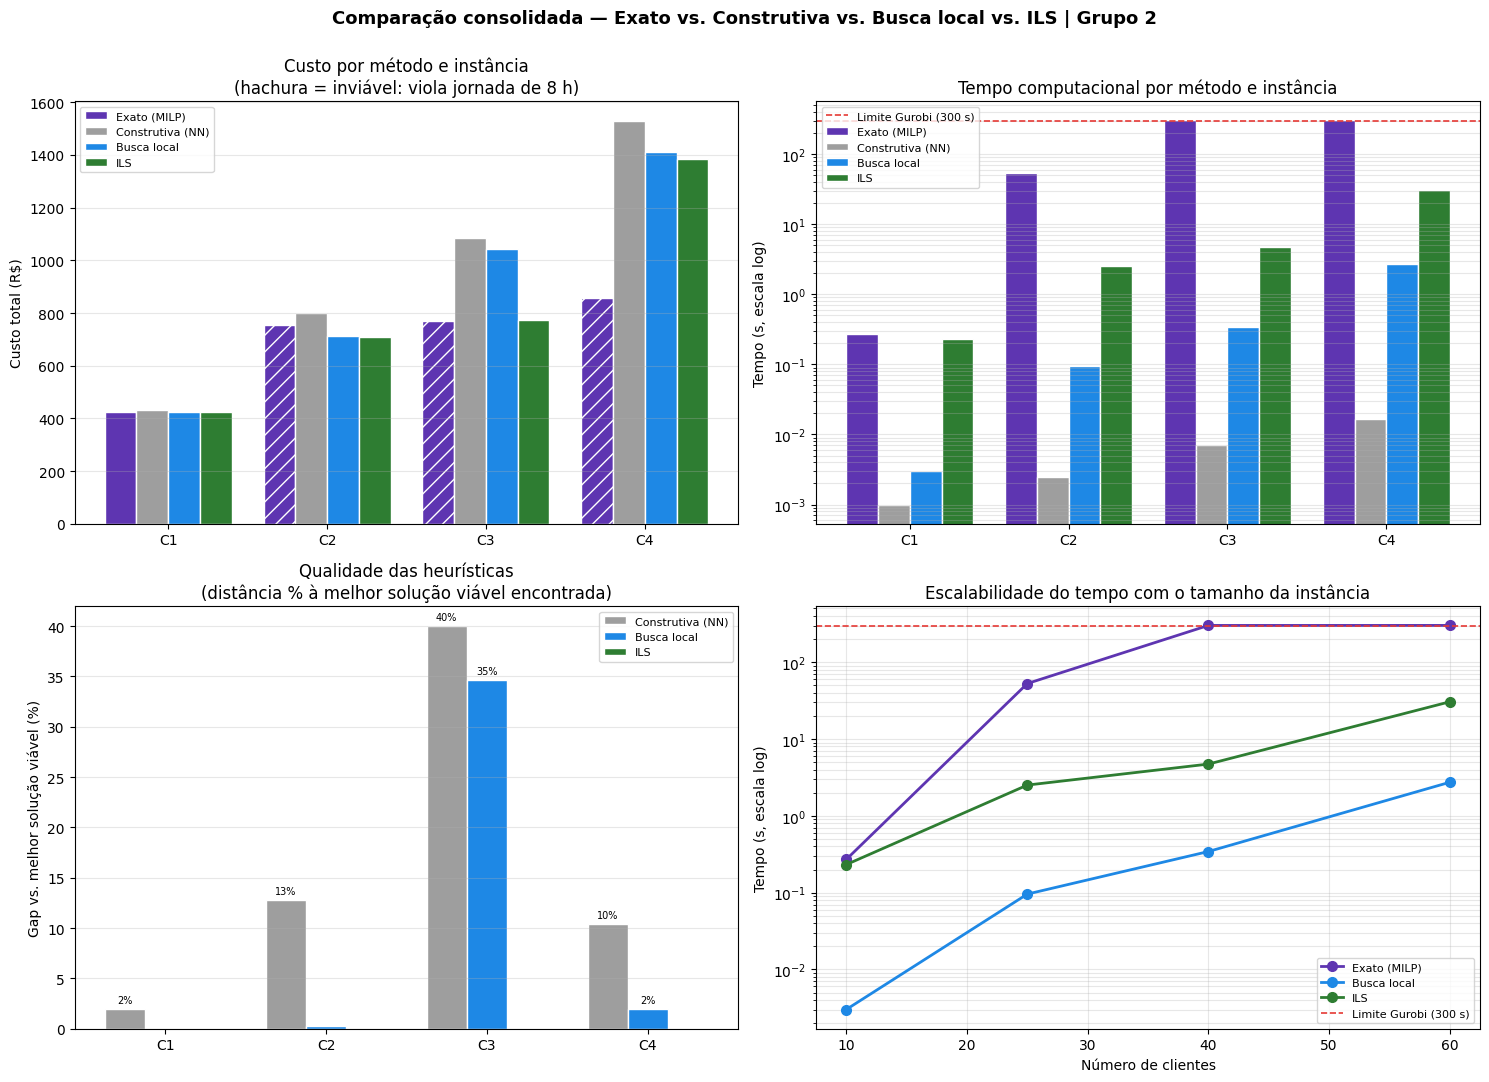

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
instancias = list(INSTANCIAS)
x = np.arange(len(instancias))
ncli = [INST[n]["n_cli"] for n in instancias]
cor = {"Exato (MILP)": CORES["exato"], "Construtiva (NN)": CORES["construtiva"],
       "Busca local": CORES["busca_local"], "ILS": CORES["ils"]}

def sub_metodo(m):
    return df_comp[df_comp["metodo"] == m].set_index("instancia").reindex(instancias)

# Painel A - custo por metodo e instancia
ax = axes[0, 0]; w = 0.2
for i, m in enumerate(ORDEM):
    s = sub_metodo(m)
    ax.bar(x + (i - 1.5) * w, s["custo_rs"], w, label=m, color=cor[m],
           hatch=["" if v else "//" for v in s["viavel"]], edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(instancias)
ax.set_ylabel("Custo total (R$)")
ax.set_title("Custo por método e instância\n(hachura = inviável: viola jornada de 8 h)")
ax.legend(fontsize=8); ax.grid(True, axis="y", alpha=0.3)

# Painel B - tempo por metodo e instancia (escala log)
ax = axes[0, 1]
for i, m in enumerate(ORDEM):
    s = sub_metodo(m)
    ax.bar(x + (i - 1.5) * w, s["tempo_s"].clip(lower=1e-3), w, label=m, color=cor[m], edgecolor="white")
ax.axhline(300, color="#E53935", ls="--", lw=1.2, label="Limite Gurobi (300 s)")
ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels(instancias)
ax.set_ylabel("Tempo (s, escala log)")
ax.set_title("Tempo computacional por método e instância")
ax.legend(fontsize=8); ax.grid(True, axis="y", alpha=0.3, which="both")

# Painel C - qualidade das heuristicas (gap vs melhor viavel)
ax = axes[1, 0]; wc = 0.25
for i, m in enumerate(["Construtiva (NN)", "Busca local", "ILS"]):
    s = sub_metodo(m)
    bars = ax.bar(x + (i - 1) * wc, s["gap_pct"], wc, label=m, color=cor[m], edgecolor="white")
    for b, v in zip(bars, s["gap_pct"]):
        if v > 1:
            ax.text(b.get_x() + b.get_width() / 2, v + 0.6, f"{v:.0f}%", ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(instancias)
ax.set_ylabel("Gap vs. melhor solução viável (%)")
ax.set_title("Qualidade das heurísticas\n(distância % à melhor solução viável encontrada)")
ax.legend(fontsize=8); ax.grid(True, axis="y", alpha=0.3)

# Painel D - escalabilidade do tempo
ax = axes[1, 1]
for m in ["Exato (MILP)", "Busca local", "ILS"]:
    s = sub_metodo(m)
    ax.plot(ncli, s["tempo_s"].clip(lower=1e-3), "o-", color=cor[m], label=m, lw=2, markersize=7)
ax.axhline(300, color="#E53935", ls="--", lw=1.2, label="Limite Gurobi (300 s)")
ax.set_yscale("log"); ax.set_xlabel("Número de clientes")
ax.set_ylabel("Tempo (s, escala log)")
ax.set_title("Escalabilidade do tempo com o tamanho da instância")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which="both")

plt.suptitle("Comparação consolidada — Exato vs. Construtiva vs. Busca local vs. ILS | Grupo 2",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(OUT_IMAGES / "comparacao_consolidada.png", dpi=150, bbox_inches="tight")
plt.show()

O painel de custo mostra que, fora de C1, o exato (roxo, hachurado) nunca entrega uma solução utilizável: em C2 sua barra é mais alta que a das heurísticas, e em C3 e C4 ela é mais baixa apenas porque viola a jornada. As barras viáveis — construtiva, busca local e ILS — contam a história relevante, com a construtiva sempre acima e busca local e ILS quase coladas, exceto em C3.

Os dois painéis de tempo são o argumento mais forte contra o exato. Em escala logarítmica, o tempo do Gurobi salta de 0,27 s em C1 para a barreira dos 300 s já em C3, encostando na linha vermelha do limite. A curva de escalabilidade deixa o ponto de virada explícito: entre 25 e 40 clientes o exato cruza para o platô de timeout, enquanto a busca local e o ILS crescem de forma suave e permanecem duas a três ordens de grandeza abaixo. Para o porte de operação da Prolog, o exato está fora de questão por tempo antes mesmo de entrar a questão da viabilidade.

O painel de qualidade resume a divisão de trabalho entre as heurísticas. O ILS é a referência viável (gap zero) em todas as instâncias. A busca local sozinha já chega muito perto — 0% em C1, 0,28% em C2, 2% em C4 —, e o único ponto em que destoa é C3 (35%), o artefato de não idempotência discutido nas Seções 2 e 3. A construtiva pura deixa de 2% a 40% sobre a mesa, o que justifica sempre encadear ao menos a busca local. O ILS agrega um polimento final consistente, porém pequeno fora de C3.

## Seção 4 — Síntese e recomendação por tamanho de instância

A pergunta de abertura era qual abordagem é mais adequada a cada tamanho de instância. A comparação consolidada responde por faixas.

Para instâncias muito pequenas, da ordem de dez clientes, o método exato é a escolha natural: em C1 o Gurobi prova o ótimo de R$ 422,38 em 0,27 s, e essa garantia de otimalidade é um ativo que nenhuma heurística oferece. Vale notar, porém, que a busca local e o ILS alcançam o mesmo valor em tempo igualmente desprezível — o exato ganha pela prova, não pelo custo.

Para instâncias médias, a partir de 25 clientes, o exato já perde nos dois critérios que importam. Em C2 ele consome 52,69 s, quase duzentas vezes o tempo de C1, e devolve uma solução que viola a jornada e ainda custa mais que a heurística (R$ 754,04 contra R$ 710,47), porque sua formulação relaxada o empurra para um único VUC. O ponto de virada da intratabilidade fica entre 25 e 40 clientes: em C3 e C4 o solver esgota os 300 s sem provar otimalidade e produz rotas de 10 h e 15 h, inexequíveis. Daí em diante o exato deixa de ser uma opção de planejamento e passa, no máximo, a um limite inferior de referência caso seja reformulado com capacidade por rota e jornada.

Para a operação real da Prolog, em qualquer porte, a recomendação é o pipeline heurístico. A heurística construtiva Nearest Neighbor dá um ponto de partida em frações de segundo, mas deixa de 2% a 40% sobre a mesa e nunca deve ser usada isolada. A busca local 2-opt + Relocate + Swap é a etapa que mais reduz custo e roda em menos de 3 s mesmo em C4; ela é a base obrigatória. O ILS com a configuração da Equipe 2 — double-bridge, critério estrito, `k = 2`, 50 a 100 iterações — entrega o polimento final e a melhor solução viável em todas as instâncias, ao custo de até cerca de meio minuto em C4. Esse polimento é pequeno fora de C3, mas barato o suficiente para se justificar sempre que houver janela de cálculo. A leitura central das Sprints 2 e 3 se confirma: a busca local faz o grosso do trabalho, o ILS refina, e o exato serve de garantia apenas onde o problema é pequeno o bastante para ser resolvido e sua formulação coincide com as restrições reais — o que, nesta base, ocorre somente em C1.

### 4.1 Salvamento de artefatos

A tabela consolidada e a figura comparativa são gravadas em `files/` e `images/` para alimentar o relatório de análise comparativa final da Sprint 3 (EAP 1.4.3). São exportações justificadas por consumo externo — o relatório —, não armazenamento de resultados intermediários.

In [9]:
# Salva a tabela consolidada (a figura ja foi gravada na Secao 3.2)
p_csv = OUT_FILES / "comparacao_consolidada.csv"
df_comp.to_csv(p_csv, index=False, encoding="utf-8")

print("Arquivos gravados:")
print(" - files/", p_csv.name)
print(" - images/ comparacao_consolidada.png")

Arquivos gravados:
 - files/ comparacao_consolidada.csv
 - images/ comparacao_consolidada.png
